# Imports

In [ ]:
from google.colab import files
import io
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
The dataset used is "Resale flat prices based on registration date from Jan-2017 onwards" from data.gov.sg.

The version of the dataset used is the one as of 4th May, which has 230,058 rows of data.

Dataset link: https://data.gov.sg/datasets?topics=housing&resultId=d_8b84c4ee58e3cfc0ece0d773c8ca6abc

---

As training and testing sets are not provided for this dataset, the data will have to be split manually. However, it cannot be split randomly, as the test set must represent unseen future data. Therefore we will be using all data from 2026 to simulate future data.


In [ ]:
# Remove file from colab environment if it already exists, to prevent multiple uploads when running code cell
!rm -rf SG_resale_prices_2017-2026.csv

# Create dictionary and store the data files
uploaded = files.upload()

# List all files and directories in the current working directory
print(os.listdir('.'))

# List files in uploaded
print(uploaded.keys())

df = pd.read_csv(io.BytesIO(uploaded['SG_resale_prices_2017-2026.csv']))

Saving SG_resale_prices_2017-2026.csv to SG_resale_prices_2017-2026.csv
['.config', 'SG_resale_prices_2017-2026.csv', 'ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv', 'sample_data']
dict_keys(['SG_resale_prices_2017-2026.csv'])


In [ ]:
# View first and last few rows of data
display(df)

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0
...,...,...,...,...,...,...,...,...,...,...,...
230627,2026-03,YISHUN,EXECUTIVE,877,YISHUN ST 81,10 TO 12,142.0,Apartment,1987,60 years 10 months,980000.0
230628,2026-03,YISHUN,EXECUTIVE,836,YISHUN ST 81,10 TO 12,146.0,Maisonette,1988,61 years,995000.0
230629,2026-03,YISHUN,EXECUTIVE,877,YISHUN ST 81,07 TO 09,142.0,Apartment,1987,60 years 10 months,980000.0
230630,2026-04,YISHUN,EXECUTIVE,827,YISHUN ST 81,01 TO 03,145.0,Maisonette,1987,60 years 06 months,960000.0


# Data Visualisation & Pre-processing


### 1. Transform time-related data

The features 'month' and 'remaining_lease' are related to time and therefore must be transformed from string format to new continuous features to allow the model to learn trends to predict future data.
- 'months_since_jan_2017' feature:
    - Since the data starts from Jan 2017, it will be used as the starting point
    - Convert 'month' to datetime datatype, then extract the year and month values
    - Subtract '2017' from the year and '01' from the month
    - Multiply the resulting year by 12 and sum both values

- 'remaining_lease_year' feature:
    - Extract year and month values from the strings
    - Divide month by 12 and sum both values

In [ ]:
# View datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230632 entries, 0 to 230631
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                230632 non-null  object 
 1   town                 230632 non-null  object 
 2   flat_type            230632 non-null  object 
 3   block                230632 non-null  object 
 4   street_name          230632 non-null  object 
 5   storey_range         230632 non-null  object 
 6   floor_area_sqm       230632 non-null  float64
 7   flat_model           230632 non-null  object 
 8   lease_commence_date  230632 non-null  int64  
 9   remaining_lease      230632 non-null  object 
 10  resale_price         230632 non-null  float64
dtypes: float64(2), int64(1), object(8)
memory usage: 19.4+ MB


In [ ]:
df_transformed = df.copy()
# Convert 'month' to datetime objects
df_transformed['month_dt'] = pd.to_datetime(df['month'])

# Create start_date variable for Jan 2017
start_date = pd.to_datetime('2017-01-01')

# Create months since January 2017 feature
df_transformed['months_since_jan_2017'] = ((df_transformed['month_dt'].dt.year - start_date.year) * 12 + \
                                 (df_transformed['month_dt'].dt.month - start_date.month)).astype('int64')


# Convert 'remaining_lease' to a continuous value
def extract_years(lease_str):
    if pd.isna(lease_str):
        return None
    parts = lease_str.split(' ')
    years = 0.0
    months = 0.0

    if 'years' in parts:
        years_idx = parts.index('years')
        years = float(parts[years_idx - 1])
    elif 'year' in parts:
        years_idx = parts.index('year')
        years = float(parts[years_idx - 1])

    if 'months' in parts:
        months_idx = parts.index('months')
        months = float(parts[months_idx - 1])
    elif 'month' in parts:
        months_idx = parts.index('month')
        months = float(parts[months_idx - 1])

    return years + (months / 12.0)

df_transformed['remaining_lease_years'] = df['remaining_lease'].apply(extract_years)

# Display the new columns
display(df_transformed[['month', 'months_since_jan_2017', 'remaining_lease', 'remaining_lease_years']])

# Drop the original 'remaining_lease' column, 'month' will still be used for feature engineering
df_transformed = df_transformed.drop(['remaining_lease'], axis=1)

,month,months_since_jan_2017,remaining_lease,remaining_lease_years
0,2017-01,0,61 years 04 months,61.333333
1,2017-01,0,60 years 07 months,60.583333
2,2017-01,0,62 years 05 months,62.416667
3,2017-01,0,62 years 01 month,62.083333
4,2017-01,0,62 years 05 months,62.416667
...,...,...,...,...
230627,2026-03,110,60 years 10 months,60.833333
230628,2026-03,110,61 years,61.000000
230629,2026-03,110,60 years 10 months,60.833333
230630,2026-04,111,60 years 06 months,60.500000


### 2. Drop unused features
- The continuous feature 'lease_commence_date' has overlap with 'remaining_lease_years', as the lease commencement date can be calculated using the remaining duration on the lease as well as the current date, which is provided by 'months_since_jan_2017'. Therefore, to avoid issues with multi-collinearity, drop 'lease_commence_date'.

- Drop 'block' and 'street_name' as there are too many categories to one-hot-encode. The model will still be able to use 'town' to learn the effect of location on the resale prices.




In [ ]:
categorical_cols = ['town', 'flat_type', 'block', 'street_name', 'storey_range', 'flat_model']

# To describe specific columns, select them first and then call .describe()
df_transformed[categorical_cols].describe()

,town,flat_type,block,street_name,storey_range,flat_model
count,230632,230632,230632,230632,230632,230632
unique,26,7,2759,577,17,21
top,SENGKANG,4 ROOM,2,YISHUN RING RD,04 TO 06,Model A
freq,18739,97844,694,3275,52888,82780


In [ ]:
df_dropCols = df_transformed.drop(['lease_commence_date', 'block', 'street_name'], axis=1)

### 3. Handle missing values and duplicate rows

In [ ]:
# Check for missing values
missing_val_check = df_dropCols.isnull().any()

print("Columns with missing values: ")
display(missing_val_check)

# Check for and remove duplicate rows
print('Before: ')
print('Number of duplicate rows: ', df_dropCols.duplicated().sum())

df_dropCols = df_dropCols.drop_duplicates()
print('After: ')
print('Number of duplicate rows: ', df_dropCols.duplicated().sum())

Columns with missing values: 


,0
month,False
town,False
flat_type,False
storey_range,False
floor_area_sqm,False
flat_model,False
resale_price,False
month_dt,False
months_since_jan_2017,False
remaining_lease_years,False


Before: 
Number of duplicate rows:  753
After: 
Number of duplicate rows:  0


### 4. Feature Engineering

By transforming the 'month' column to 'months_since_jan_2017', any relationship between the month alone and the resale prices (e.g. seasonal trends) were lost. Therefore, a new categorical feature 'month_sold' will be created.

In [ ]:
df_newCol = df_dropCols.copy()

# Create a 'month_sold' column by extracting the month number from datetime month column
df_newCol['month_sold'] = df_dropCols['month_dt'].dt.month

display(df_newCol[['month', 'month_sold']])

# Drop the datetime and original 'month' column
df_newCol = df_newCol.drop(['month_dt', 'month'], axis=1)

,month,month_sold
0,2017-01,1
1,2017-01,1
2,2017-01,1
3,2017-01,1
4,2017-01,1
...,...,...
230627,2026-03,3
230628,2026-03,3
230629,2026-03,3
230630,2026-04,4


### 5. Split data into training and testing sets

Training: Data from Jan 2017 - Dec 2025 (223661 rows)

Testing: Data from Jan 2026 - April 2026 (5644 rows)

In [ ]:
Train_df = df_newCol[df_newCol['months_since_jan_2017'] <= 108]
Test_df = df_newCol[df_newCol['months_since_jan_2017'] > 108]

print(len(Train_df))
print(len(Test_df))

223661
6218


### 6. Histogram and Box Plots of continuous features

Histograms are used to check the distribution of the data in order to detect if it is skewed. Based on the histograms of the 4 continuous features, we can see that:
- 'floor_area_sqm' and 'resale_price' are right skewed.
- 'remaining_lease years' is multimodal as it has 3 distinct peaks. It is also left skewed.
- 'months_since_jan_2017' is uniformly distributed, with small spikes at certain points. These could be due to seasonal trends that result in increased number of purchases.

The three peaks in 'remaining_lease_years' possibly reflects the three age groups of HDBs that are more popularly put up for resale. The skewness to the left reflects that HDBs with longer remaining leases are more likely to be put up for resale than HDBs with shorter remaining leases. This information will be useful to the models, which is why we have decided not to modify this feature's distribution.

We will be using log transformation to reduce the skewness of 'floor_area_sqm' and 'resale_price'.

---

Box plots are used to detects outliers using the IQR method, where the whiskers refer to (Q1 - 1.5 * IQR) and (Q3 + 1.5 * IQR), and any points beyond the whiskers are lesser/greater than these values and considered outliers. Based on the box plots:
- 'floor_area_sqm' and 'resale_price' both have many outliers, meaning they are unlikely to be caused by data entry errors, and may still be useful for prediction.
- 'remaining_lease_years' and 'month_since_jan_2017' do not have any outliers. Because they are related to time, any outliers in these features would likely be data entry errors.

We have decided to leave the outliers in the data for the initial model. Depending on its performance, the outliers may be removed.

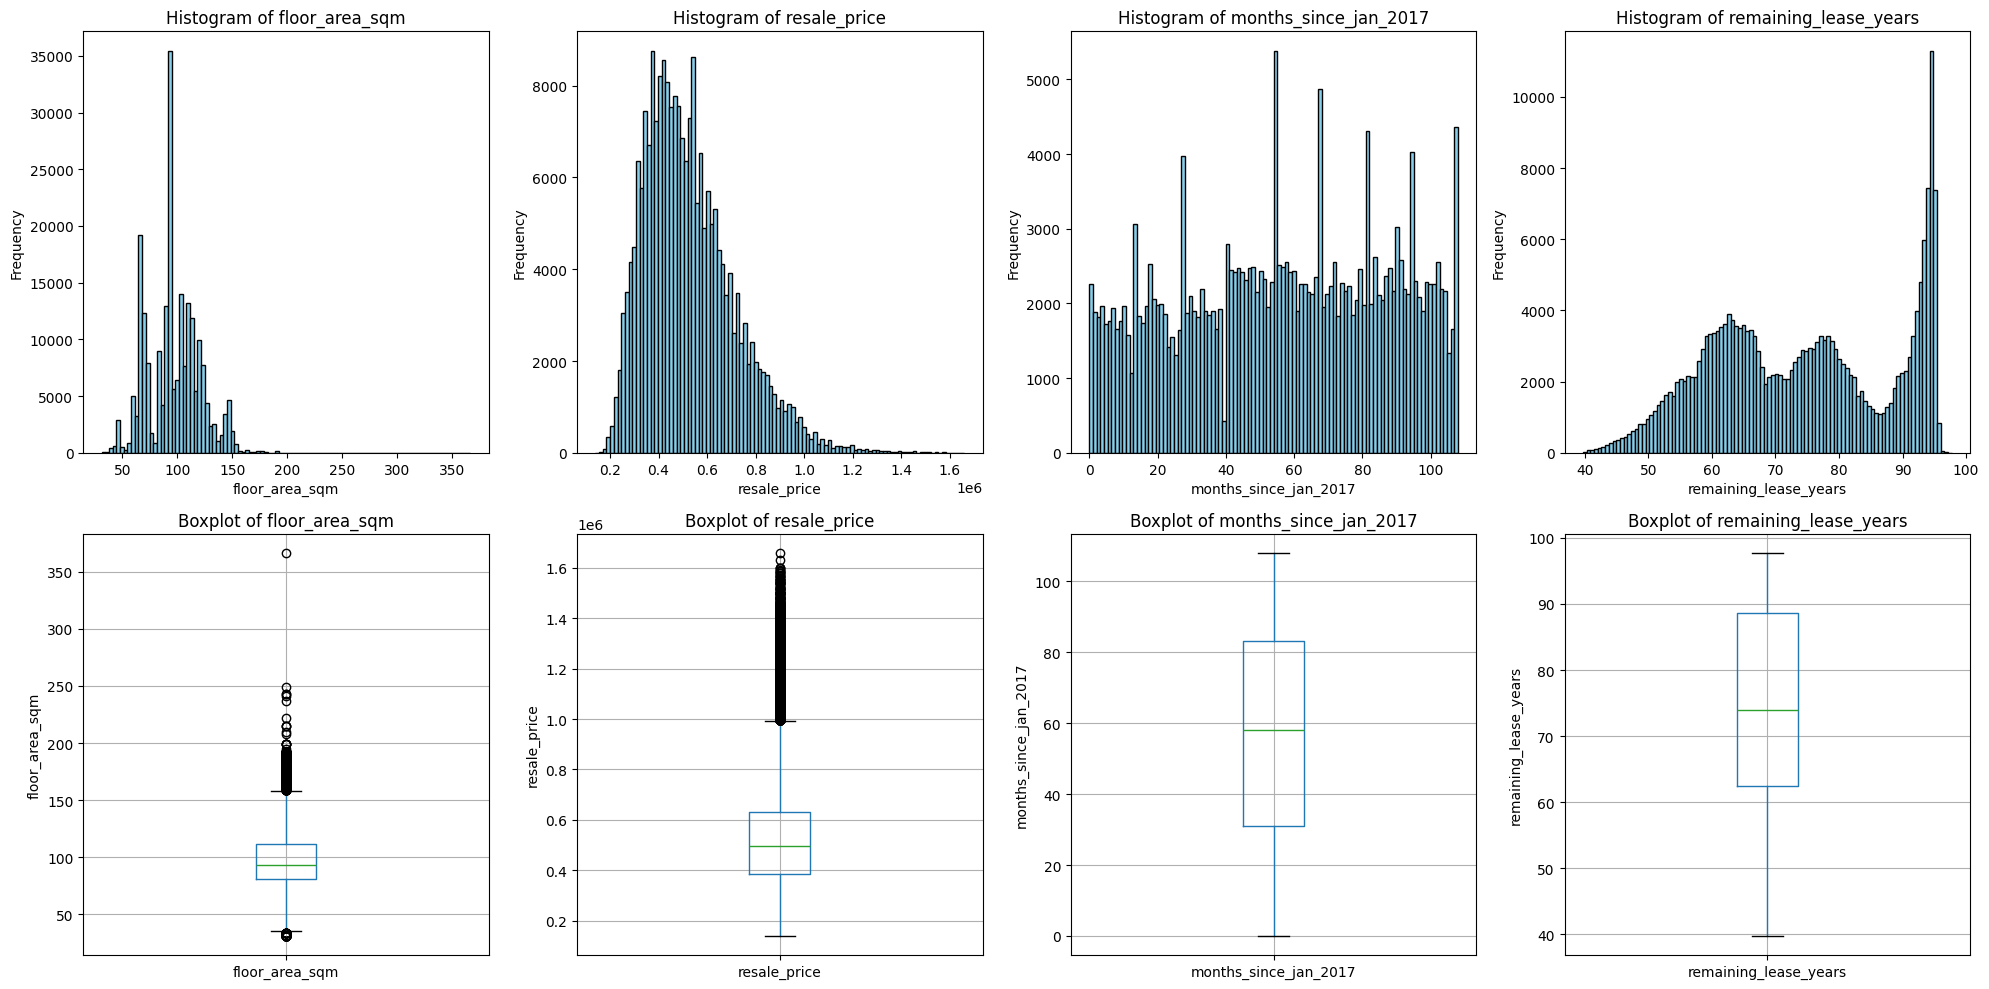

In [ ]:
# Graph of distributions for continuous columns

# Select continuous columns
continuous_cols = ['floor_area_sqm', 'resale_price', 'months_since_jan_2017', 'remaining_lease_years']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Plot Histograms
for idx, col_name in enumerate(continuous_cols):
    current_col_data = Train_df[col_name]
    ax = axes[0, idx]
    ax.hist(current_col_data, bins=100, color='skyblue', edgecolor='black')
    ax.set_title(f'Histogram of {col_name}')
    ax.set_xlabel(col_name)
    ax.set_ylabel('Frequency')

# Plot Boxplots
for idx, col_name in enumerate(continuous_cols):
    ax = axes[1, idx]
    Train_df.boxplot(column=col_name, ax=ax)
    ax.set_title(f'Boxplot of {col_name}')
    ax.set_ylabel(col_name)


plt.tight_layout()
plt.show()

### 7. Bar plots of categorical features

The bar plots show that there are a few majority and minority categories in the four categorical features. Based on the bar plots:

- 'town': This feature is important for two baselines where we will create subtasks using it, so it cannot be modified.
- The relationship between 'flat_type', 'storey_range' and 'flat_model' requires domain understanding of many different variations of HDB properties in order to condense them accurately into smaller categories.

Therefore, we will not be modifying any of these features.

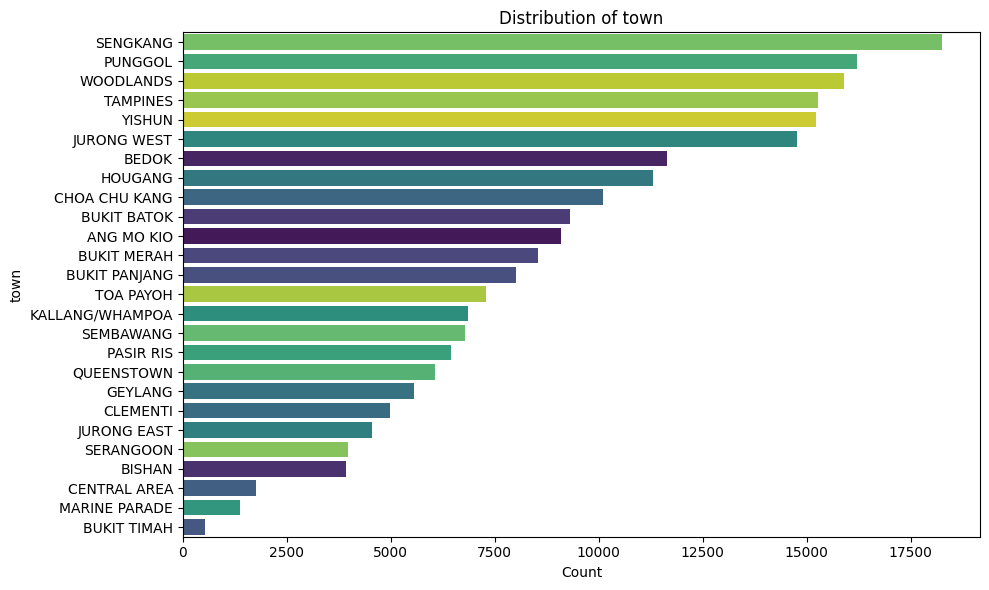

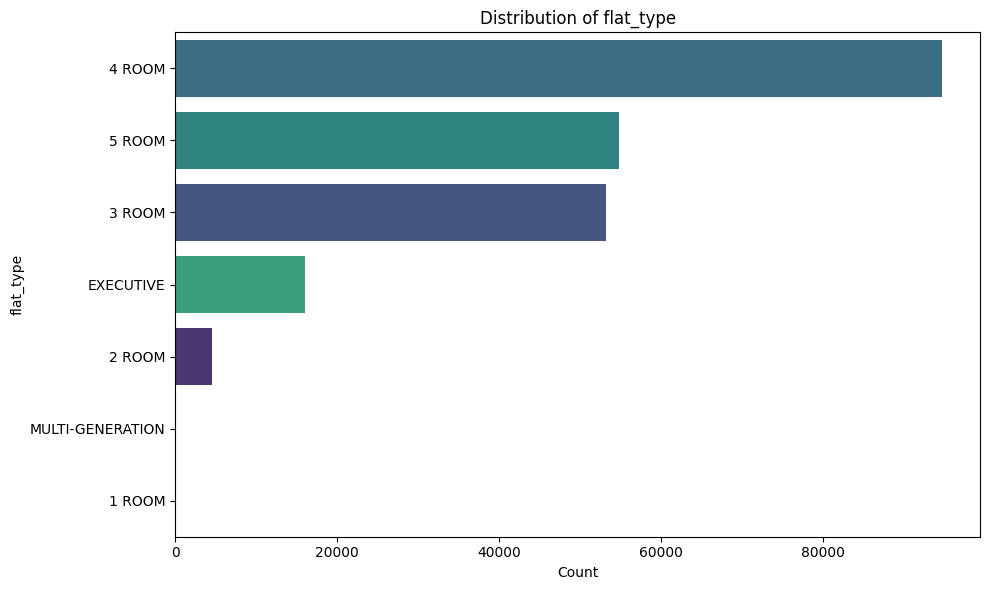

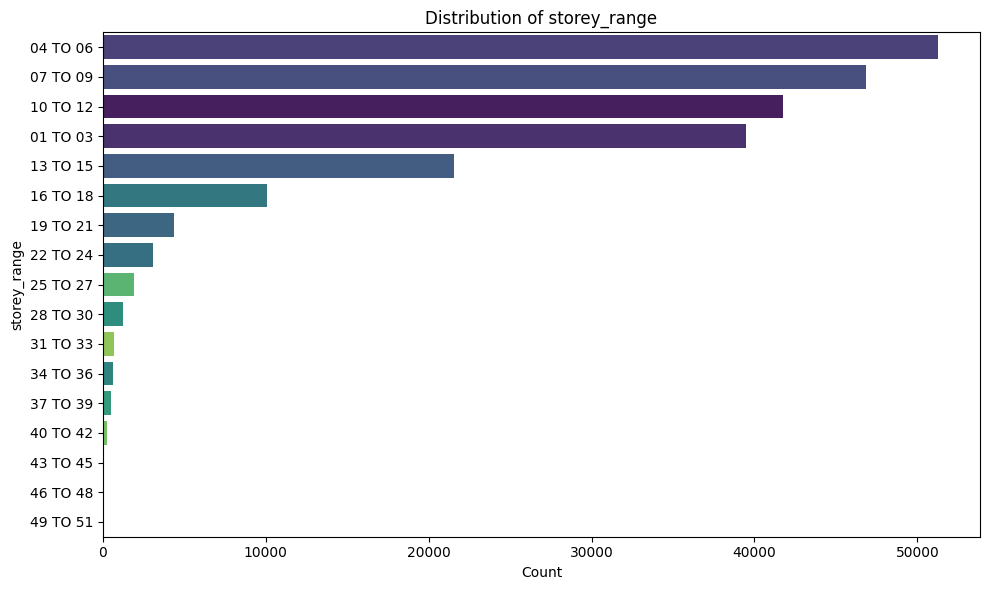

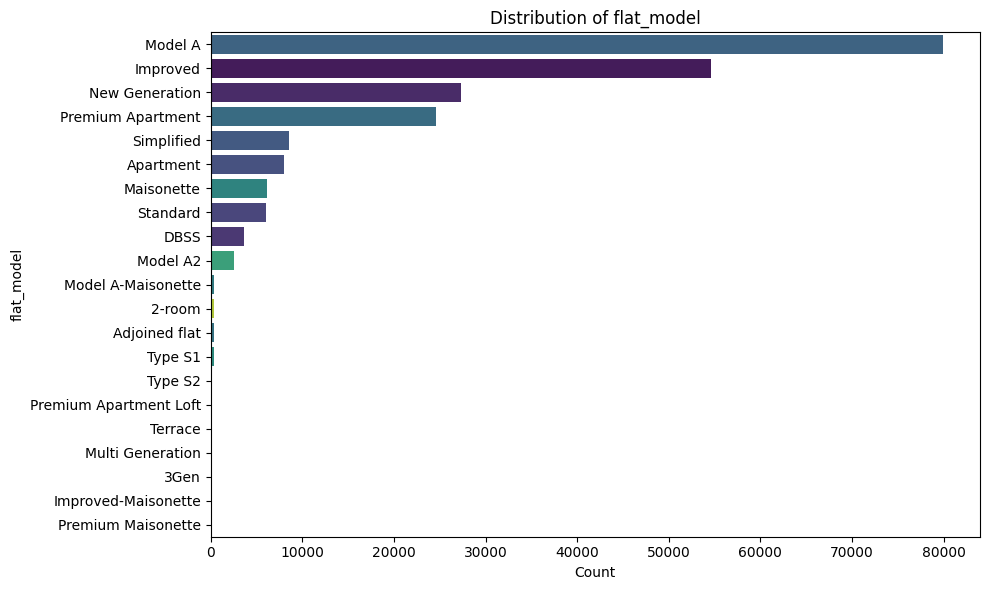

In [ ]:
# Select categorical columns
categorical_cols = ['town', 'flat_type', 'storey_range', 'flat_model']

for col_name in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=Train_df, y=col_name, hue=col_name, palette='viridis', legend=False, order=Train_df[col_name].value_counts().index)
    plt.title(f'Distribution of {col_name}')
    plt.xlabel('Count')
    plt.ylabel(col_name)
    plt.tight_layout()
    plt.show()


### 8. Apply Log Transformation to Skewed Features

Applying a log transformation to 'floor_area_sqm', 'resale_price' and 'remaining_lease_years'. We will use 'np.log1p' (log(1+x)) to handle any potential zero values.

Result: 'floor_area_sqm' and 'resale_price' now have a normal distribution.

In [ ]:
Train_df_log = Train_df.copy()
Test_df_log = Test_df.copy()

# Apply log transformation to 'floor_area_sqm' and 'resale_price'
Train_df_log['floor_area_sqm'] = np.log1p(Train_df['floor_area_sqm'])
Test_df_log['floor_area_sqm'] = np.log1p(Test_df['floor_area_sqm'])

Train_df_log['resale_price'] = np.log1p(Train_df['resale_price'])
Test_df_log['resale_price'] = np.log1p(Test_df['resale_price'])

print('Training Set after log transformation:')
display(Train_df_log.head())

print('Testing Set after log transformation:')
display(Test_df_log.head())

Training Set after log transformation:


,town,flat_type,storey_range,floor_area_sqm,flat_model,resale_price,months_since_jan_2017,remaining_lease_years,month_sold
0,ANG MO KIO,2 ROOM,10 TO 12,3.806662,Improved,12.354497,0,61.333333,1
1,ANG MO KIO,3 ROOM,01 TO 03,4.219508,New Generation,12.429220,0,60.583333,1
2,ANG MO KIO,3 ROOM,01 TO 03,4.219508,New Generation,12.476104,0,62.416667,1
3,ANG MO KIO,3 ROOM,04 TO 06,4.234107,New Generation,12.487489,0,62.083333,1
4,ANG MO KIO,3 ROOM,01 TO 03,4.219508,New Generation,12.487489,0,62.416667,1


Testing Set after log transformation:


,town,flat_type,storey_range,floor_area_sqm,flat_model,resale_price,months_since_jan_2017,remaining_lease_years,month_sold
222069,ANG MO KIO,2 ROOM,10 TO 12,3.806662,Improved,12.691584,109,51.000000,2
222070,ANG MO KIO,2 ROOM,04 TO 06,3.806662,Improved,12.577640,111,50.833333,4
222071,ANG MO KIO,2 ROOM,07 TO 09,3.806662,Improved,12.621491,111,50.750000,4
222072,ANG MO KIO,2 ROOM,10 TO 12,3.828641,Improved,12.793862,111,58.833333,4
222073,ANG MO KIO,2 ROOM,04 TO 06,3.806662,Improved,12.706851,110,53.333333,3


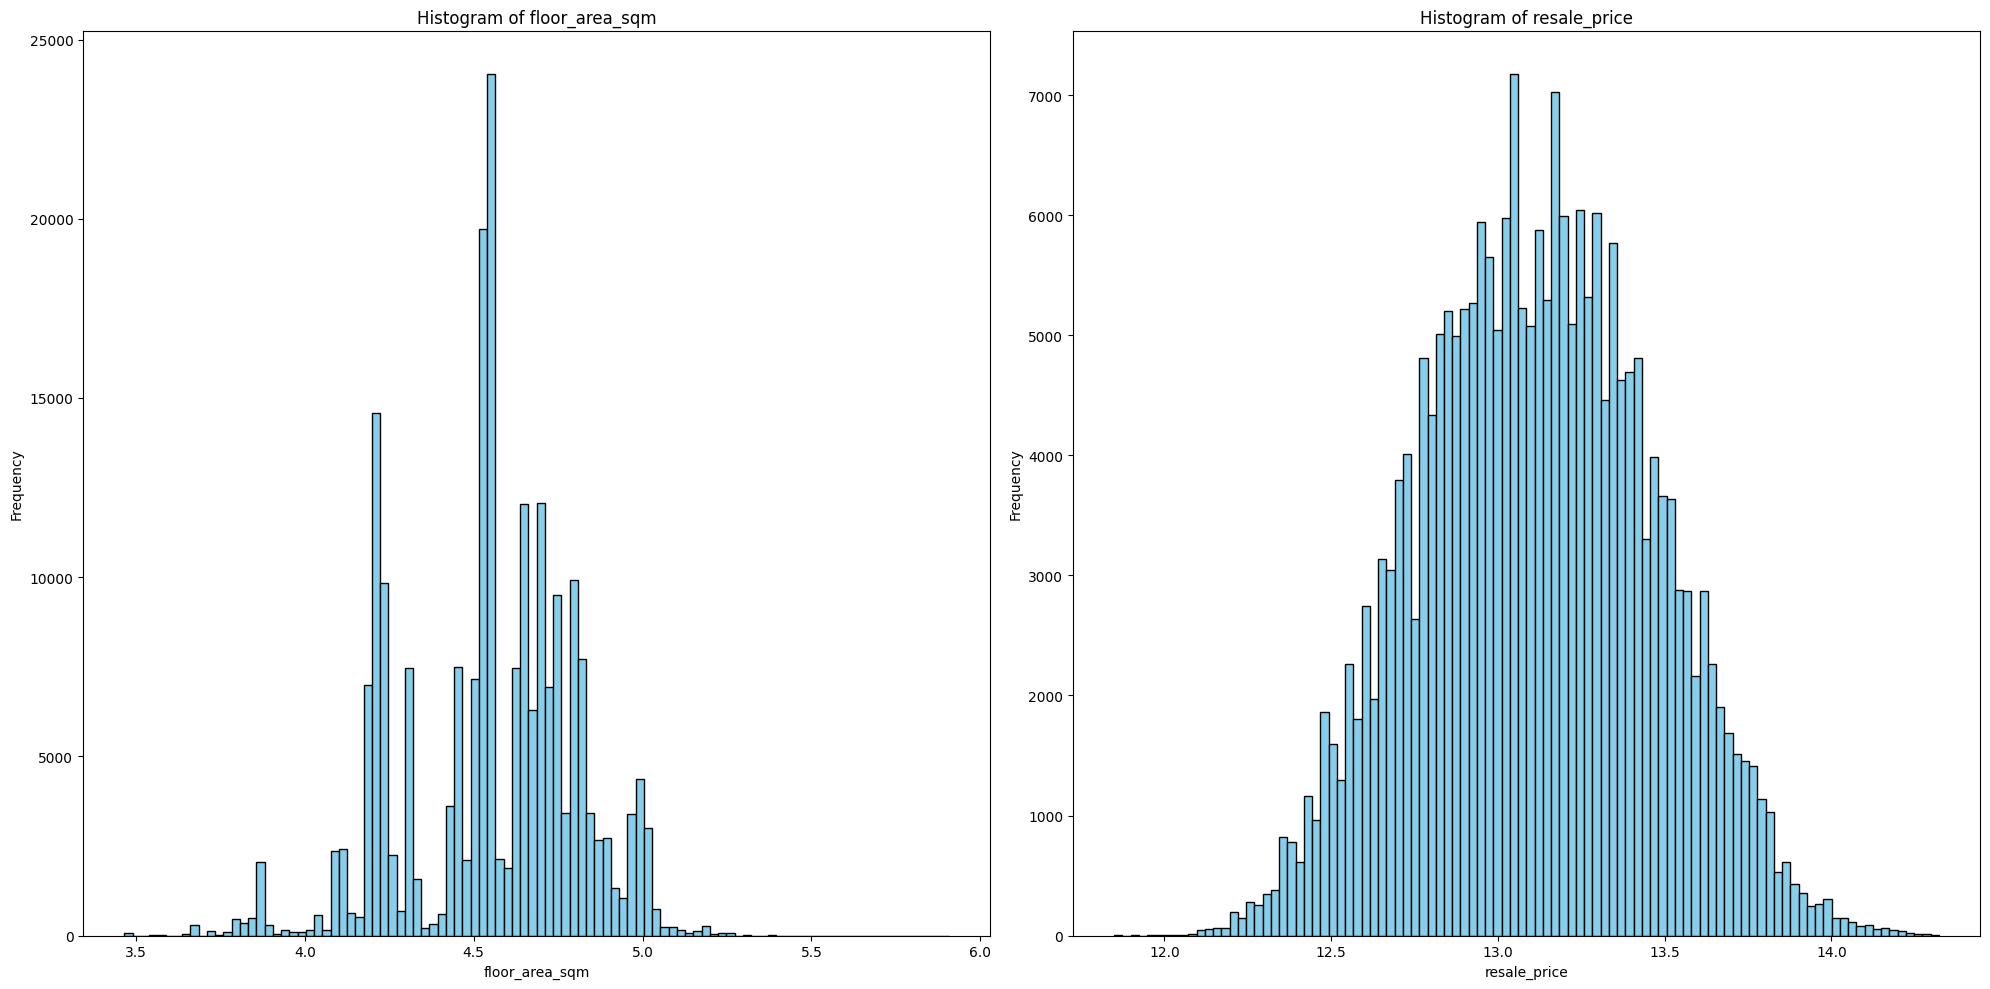

In [ ]:
# Check distribution after log transformation

cols = ['floor_area_sqm', 'resale_price']

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Plot Histograms
for idx, col_name in enumerate(cols):
    current_col_data = Train_df_log[col_name]
    ax = axes[idx]
    ax.hist(current_col_data, bins=100, color='skyblue', edgecolor='black')
    ax.set_title(f'Histogram of {col_name}')
    ax.set_xlabel(col_name)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### 9. Save the dataset

These are the 3 baselines we have decided to use:
1. Global Single-Task Approach (1 Dataset, 1 Model, 1 Output)
2. Local Single-Task Approach (X Datasets, X Models,  X Outputs)
3. Multi-Task Learning (MTL) Approach (1 Dataset, 1 Model, X Outputs)

---

There are two important steps for pre-processing remaining:
- Categorical feature encoding
- Continuous feature scaling

However, since each of the three baselines require slightly different implementations of the above steps, the datasets are saved at this point and the remaining pre-processing will be done in the 3 baselines' respective colab files.

In [ ]:
# Saves the data to .csv files
Train_df_log.to_csv('HDB_Resale_Train.csv', index=False)
Test_df_log.to_csv('HDB_Resale_Test.csv', index=False)

# Uncomment to automatically download .csv files, otherwise download from files tab
#files.download('HDB_Resale_Train.csv')
#files.download('HDB_Resale_Test.csv')